# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.



**Informasi Dataset**

Link dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

Dataset yang digunakan pada proyek ini adalah Heart Failure Prediction Dataset yang diambil dari Kaggle. Informasi atribut pada dataset dapat dilihat pada list dibawah ini.
1. Age: age of the patient [years]
2. Sex: sex of the patient [M: Male, F: Female]
3. ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
4. RestingBP: resting blood pressure [mm Hg]
5. Cholesterol: serum cholesterol [mm/dl]
6. FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
7. RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
8. MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
9. ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
10. Oldpeak: oldpeak = ST [Numeric value measured in depression]
11. ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
12. HeartDisease: output class [1: heart disease, 0: Normal]

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
data = pd.read_csv('../heart_failure_raw.csv')

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### **Data Information**

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


### **Check Missing Value**

In [5]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

### **Check Duplicate**

In [6]:
print(f"Jumlah data duplikat: {data.duplicated().sum()}")

Jumlah data duplikat: 0


### **Numerical Features Exploration**

In [7]:
numerical_features = data.select_dtypes(include=['number']).columns.tolist()

numerical_features

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease']

##### **Numeric Features Distribution**

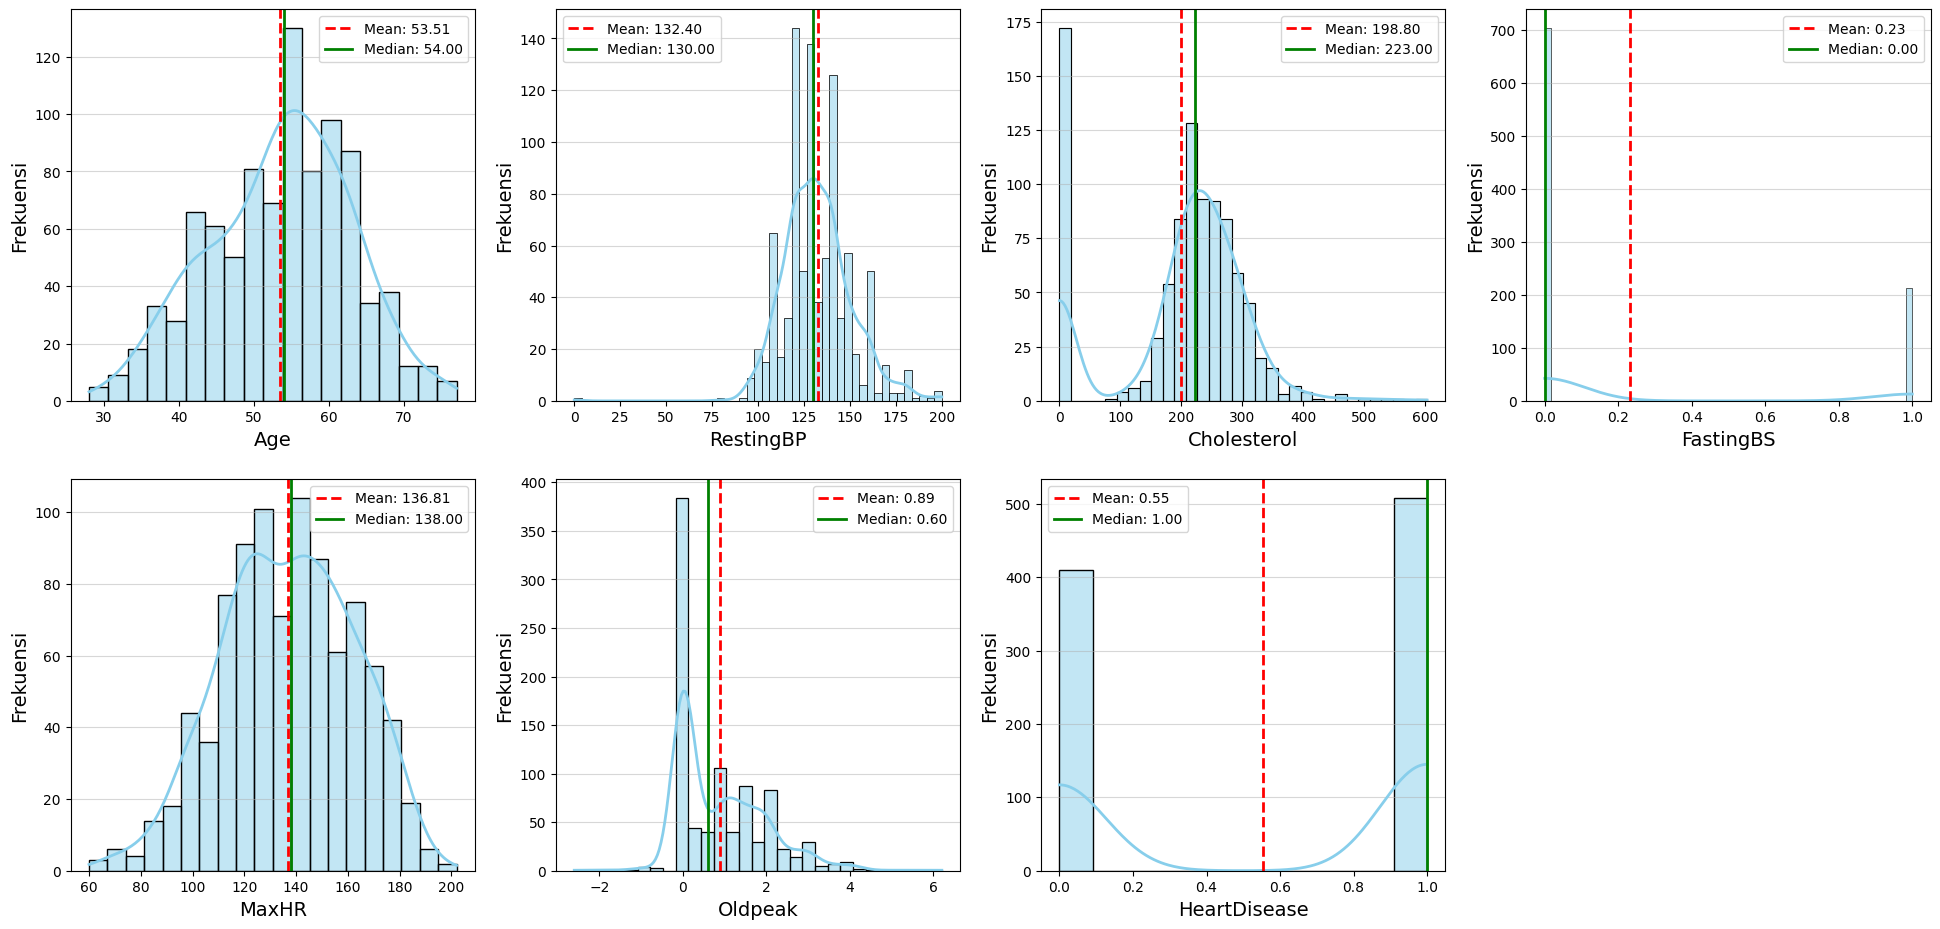

In [8]:
n_cols = 4
n_rows = (len(numerical_features) + n_cols - 1)

plt.figure(figsize=(6 * n_cols, 6 * n_rows))

for i, col in enumerate(numerical_features):
    mean_val = data[col].mean()
    median_val = data[col].median()
    
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(
        data=data,
        x=col,
        kde=True,
        color='skyblue',
        edgecolor='black',
        line_kws={'linewidth': 2}
    )

    # Menambahkan Garis Central Tendency
    # Garis Rata-rata (Mean)
    plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')

    # Garis Median
    plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

    # Menambahkan Judul dan Label
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frekuensi', fontsize=14)
    plt.legend()
    plt.grid(axis='y', alpha=0.5)

plt.show()
    

##### **Checking Outlier**

In [9]:
def check_outlier():
    plt.figure(figsize=(4 * n_cols, 4 * n_rows))

    for i, col in enumerate(numerical_features):
        plt.subplot(n_rows, n_cols, i + 1)
        sns.boxplot(y=data[col], color='lightblue')
        plt.title(col, fontsize=12)
        plt.ylabel('')
        plt.grid(axis='y', alpha=0.5)

    plt.tight_layout()
    plt.show()

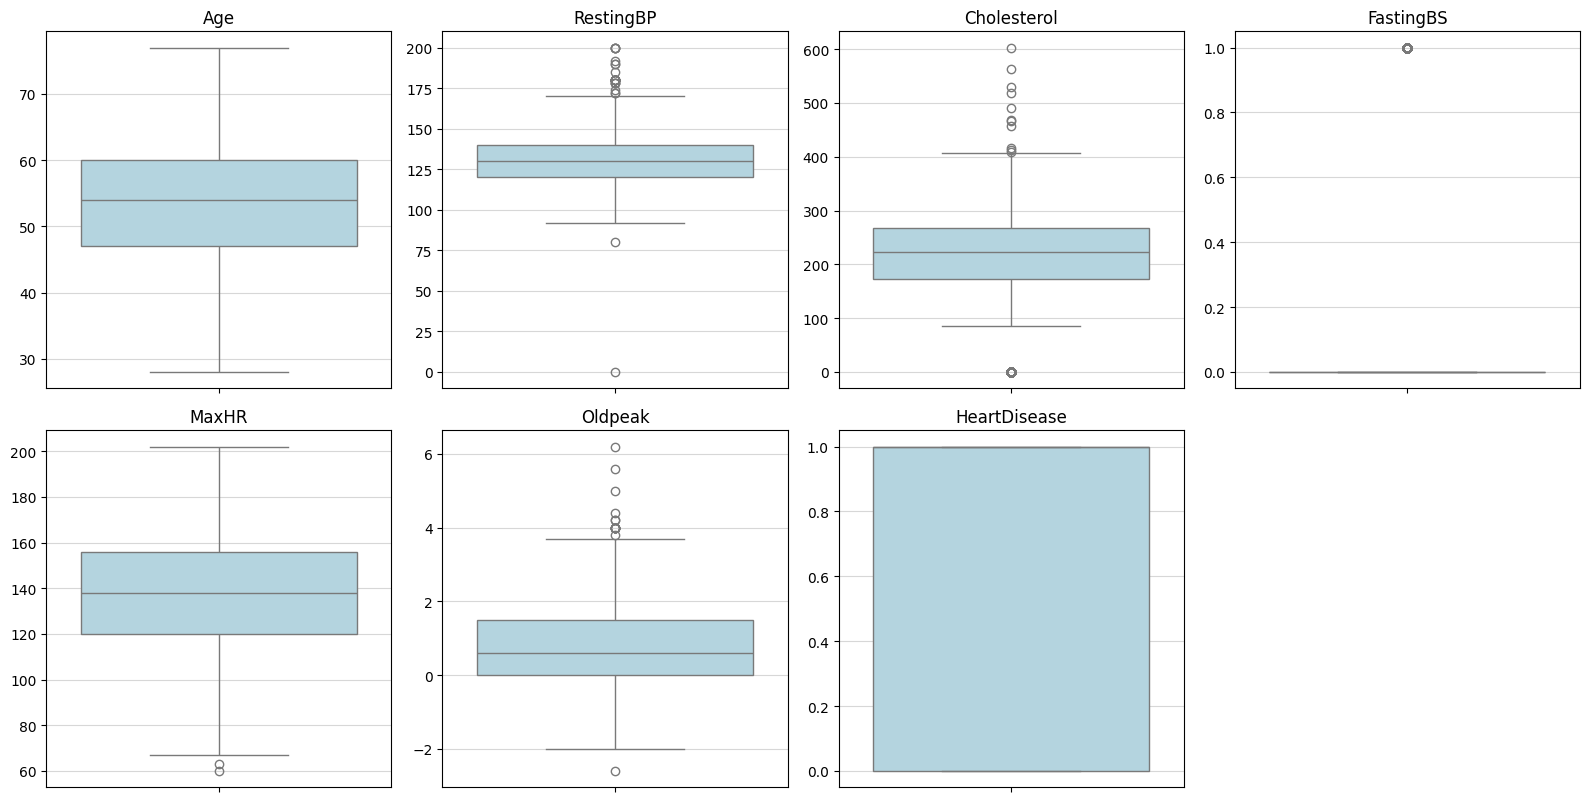

In [10]:
check_outlier()

In [11]:
feature_has_outliers = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

feature_has_outliers

['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

### **Categorical Features Exploration**

In [12]:
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

categorical_features

['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

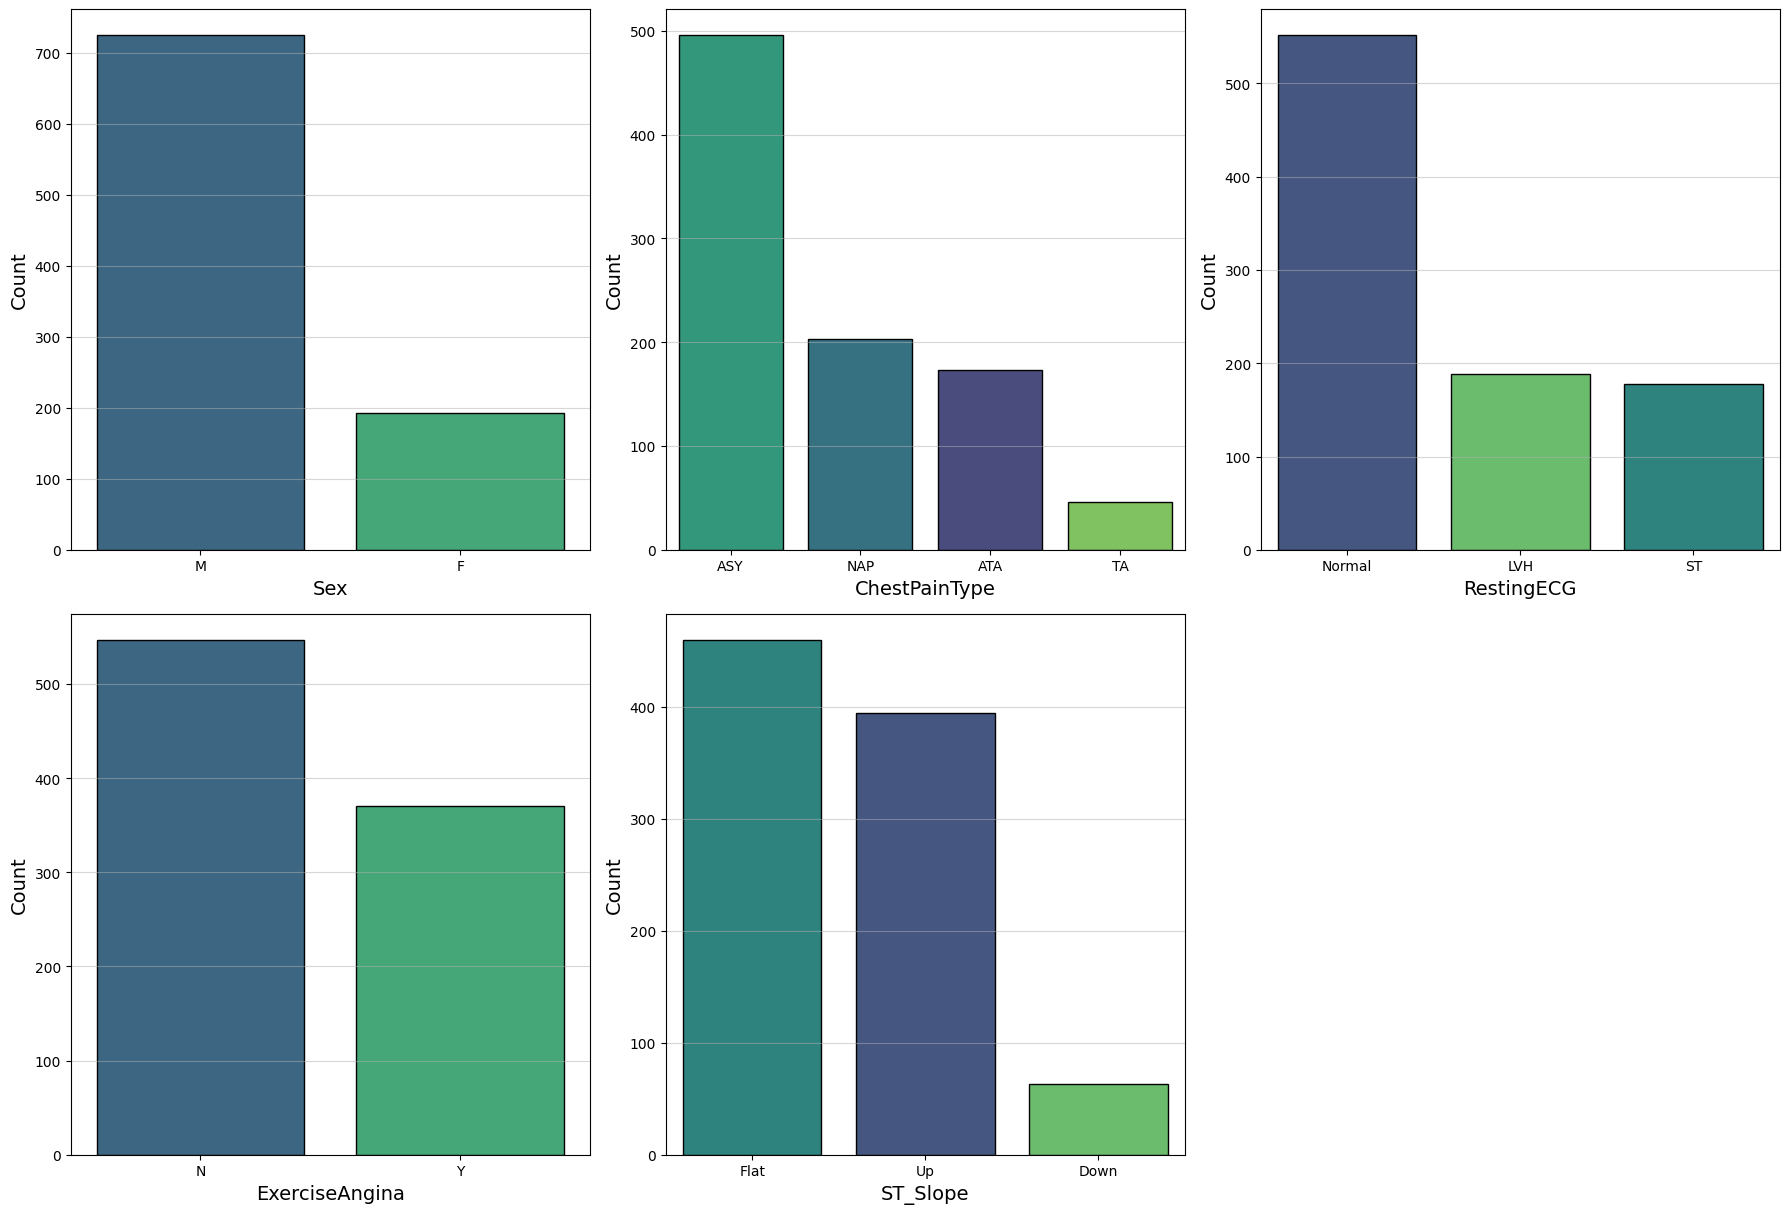

In [13]:
n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1)

plt.figure(figsize=(6 * n_cols, 6 * n_rows))

for i, col in enumerate(categorical_features):
    
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(
        data=data,
        x=col,
        edgecolor='black',
        hue=col,
        palette='viridis',
        order=data[col].value_counts().index
    )

    # Menambahkan Judul dan Label
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### **Handle Outliers**

In [14]:
for col in feature_has_outliers:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

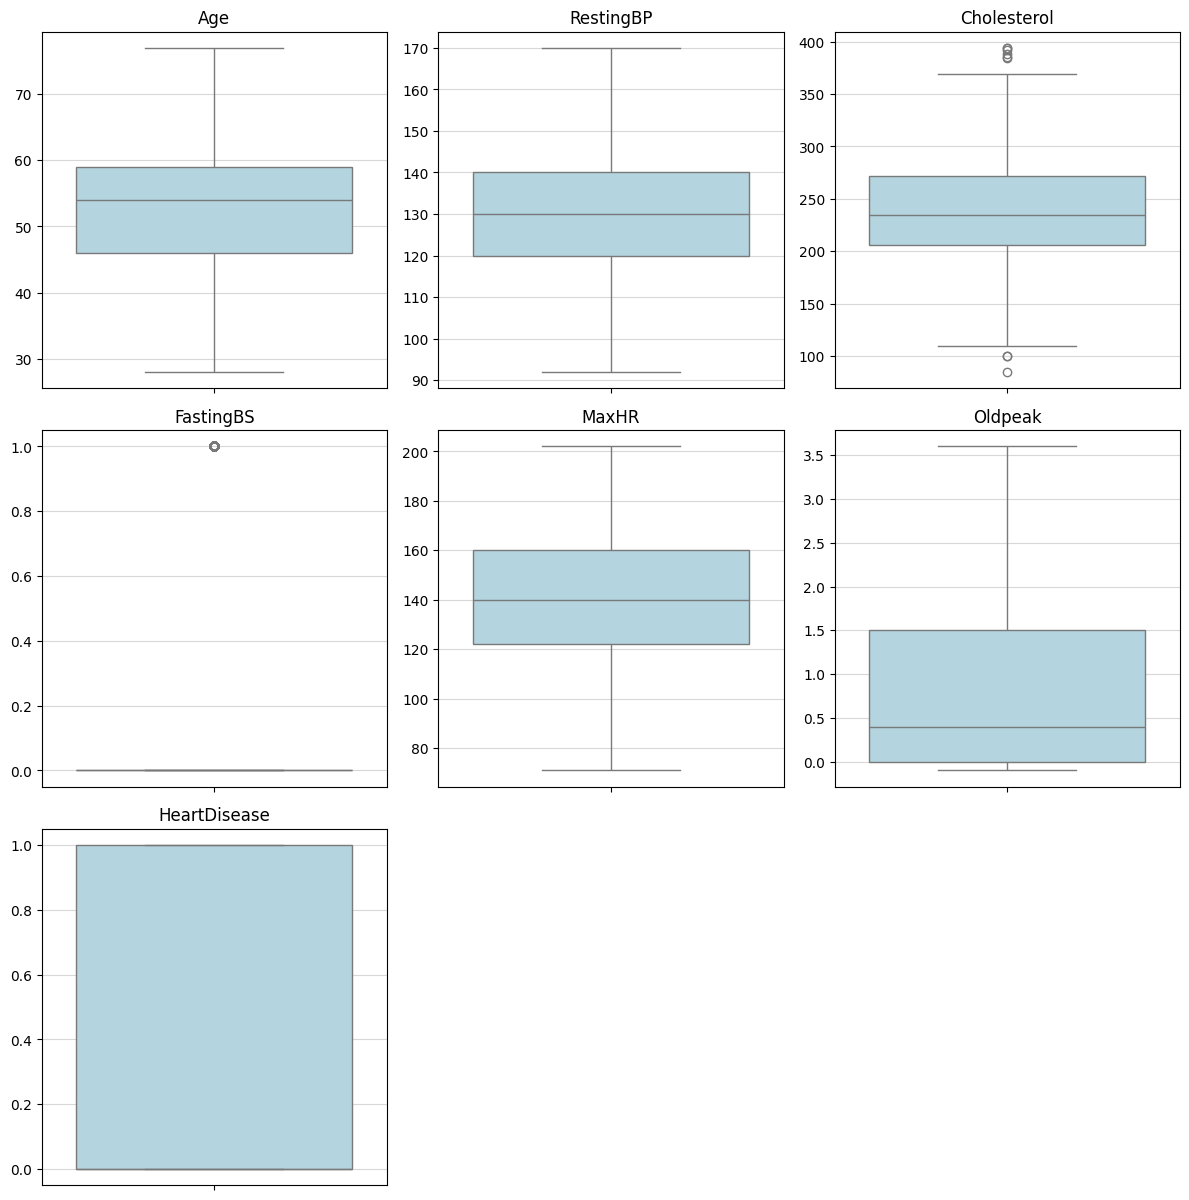

In [15]:
check_outlier()

In [16]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000,701.000000
mean,52.723252,131.544936,239.475036,0.162625,140.573466,0.829244,0.462197
std,9.542111,15.428074,50.338211,0.369287,24.370341,0.959398,0.498925
min,28.000000,92.000000,85.000000,0.000000,71.000000,-0.100000,0.000000
25%,46.000000,120.000000,206.000000,0.000000,122.000000,0.000000,0.000000
50%,54.000000,130.000000,235.000000,0.000000,140.000000,0.400000,0.000000
75%,59.000000,140.000000,272.000000,0.000000,160.000000,1.500000,1.000000
max,77.000000,170.000000,394.000000,1.000000,202.000000,3.600000,1.000000


### **Split Data**

In [17]:
X = data.drop(columns=['HeartDisease'])
y = data['HeartDisease']

if 'HeartDisease' in numerical_features:
    numerical_features.remove('HeartDisease')
if 'HeartDisease' in categorical_features:
    categorical_features.remove('HeartDisease')

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(560, 11)
(141, 11)
(560,)
(141,)


### **Numerical Data Normalization**

In [18]:
scaler = StandardScaler()

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

In [19]:
X_train.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,5.600000e+02,5.600000e+02,5.600000e+02,5.600000e+02,5.600000e+02,5.600000e+02
mean,2.759697e-16,-9.008667e-16,3.806479e-17,4.123686e-17,-3.330669e-16,-3.965082e-17
std,1.000894e+00,1.000894e+00,1.000894e+00,1.000894e+00,1.000894e+00,1.000894e+00
min,-2.628648e+00,-2.525659e+00,-3.054121e+00,-4.346949e-01,-2.848732e+00,-9.592308e-01
25%,-7.115095e-01,-7.147698e-01,-6.515014e-01,-4.346949e-01,-7.435108e-01,-8.542329e-01
50%,3.404442e-02,-6.802382e-02,-8.559511e-02,-4.346949e-01,3.959095e-02,-4.867403e-01
75%,6.730906e-01,5.787222e-01,6.391621e-01,-4.346949e-01,7.718419e-01,7.207356e-01
max,2.590229e+00,2.518960e+00,3.081495e+00,2.300464e+00,2.480427e+00,2.925691e+00


In [20]:
X_test.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
mean,0.022714,0.158567,0.065581,0.050262,-0.091683,0.081812
std,1.078887,0.978693,0.995931,1.048354,0.952686,1.033613
min,-2.309125,-2.396309,-2.557712,-0.434695,-2.157162,-0.854233
25%,-0.711509,-0.585421,-0.572076,-0.434695,-0.814702,-0.854233
50%,0.140552,0.190675,-0.035954,-0.434695,-0.041770,-0.224246
75%,0.886106,0.708071,0.738444,-0.434695,0.609119,0.825733
max,2.483721,2.518960,3.041782,2.300464,1.992260,2.925691


### **Encoding Categorical Data**

In [21]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

X_train_num = X_train[numerical_features].reset_index(drop=True)
X_test_num = X_test[numerical_features].reset_index(drop=True)

encoded_cols = encoder.get_feature_names_out(categorical_features)
X_train_cat = pd.DataFrame(X_train_encoded, columns=encoded_cols)
X_test_cat = pd.DataFrame(X_test_encoded, columns=encoded_cols)

# Menyatukan kembali
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

In [22]:
len(encoded_cols)

14

In [23]:
X_train.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.031033,0.578722,0.976720,-0.434695,-0.245173,1.245725,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-1.137540,0.578722,-0.254374,-0.434695,1.504093,-0.854233,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,1.099121,2.518960,-1.227336,-0.434695,-2.319884,1.770715,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,0.566583,1.225468,-0.393369,-0.434695,-0.936744,-0.854233,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,0.673091,-0.068024,1.969538,2.300464,-0.448576,0.720736,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [24]:
X_train.shape

(560, 20)

In [25]:
X_test.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0.460075,-1.361516,1.909969,-0.434695,0.080272,2.295704,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.072463,0.578722,0.539880,-0.434695,-0.285854,1.245725,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-2.309125,-0.714770,0.619306,-0.434695,0.487078,0.720736,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.605002,0.449373,0.361173,-0.434695,0.609119,-0.854233,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.178971,0.578722,1.195140,-0.434695,1.300690,0.825733,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [26]:
X_test.shape

(141, 20)

### **Menyimpan Dataset**

In [28]:
header_path = 'heart_failure_preprocessing/feature_header_eksperimen.csv'

# Simpan header fitur
pd.DataFrame(columns=data.columns).to_csv(header_path, index=False)
print(f"Nama kolom berhasil disimpan ke: {header_path}")

Nama kolom berhasil disimpan ke: heart_failure_preprocessing/feature_header_eksperimen.csv


In [29]:
feature_names = numerical_features + list(
    encoder
    .get_feature_names_out(categorical_features)
)

In [30]:
train_df = pd.DataFrame(X_train, columns=feature_names)
train_df['HeartDisease'] = y_train.values

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['HeartDisease'] = y_test.values

In [31]:
output_train_path = 'heart_failure_preprocessing/heart_failure_train_eksperimen.csv'
output_test_path = 'heart_failure_preprocessing/heart_failure_test_eksperimen.csv'

# Simpan hasil preprocessing
pd.DataFrame(train_df).to_csv(output_train_path, index=False)
print(f"Data train berhasil disimpan di: {output_train_path}")

pd.DataFrame(test_df).to_csv(output_test_path, index=False)
print(f"Data test berhasil disimpan di: {output_test_path}")

Data train berhasil disimpan di: heart_failure_preprocessing/heart_failure_train_eksperimen.csv
Data test berhasil disimpan di: heart_failure_preprocessing/heart_failure_test_eksperimen.csv
